#Análisis de reproducciones en Spotify

In [3]:
#Librerías necesarias
import glob
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

##ETL: Extracción, Transformación y Carga

In [4]:
# 1. DICCIONARIO DE ARTISTAS Y GÉNEROS ESPECÍFICOS
# Mapeo estructurado por Artista y Canción
GENRE_MAP = {
    "Adrián Berra": {
        "main": "Canción de Autor",
        "sub": "Indie Folk, Canción Platense",
    },
    "Ainda": {
        "main": "Indie Pop",
        "sub": "Indie Folk, Canción Pop / Canción Urbana",
    },
    "Alejandro y Maria Laura": {
        "main": "Canción de Autor",
        "sub": "Indie Pop, Folk Latinoamericano",
    },
    "Amy Winehouse": {"main": "Neo-Soul", "sub": "Soul, Ska / Reggae, R&B"},
    "Arcade Fire": {"main": "Indie Rock", "sub": "Art Rock, Alternative Rock"},
    "Arctic Monkeys": {
        "main": "Indie Rock",
        "sub": "Alternative Rock, Garage Rock",
    },
    "Axel Fiks": {"main": "Indie Pop", "sub": "R&B Urbano, Bedroom Pop"},
    "Babasonicos": {
        "main": "Rock Argentino",
        "sub": "Alternative Rock, Electro-Rock, Pop Rock",
    },
    "Bad Bunny": {
        "main": "Urbano Latino",
        "sub": "Reggaeton, Trap Latino, Synth-Pop, Mambo",
    },
    "Bersuit Vergarabat": {
        "main": "Rock Argentino",
        "sub": "Latin Rock, Ska Rock, Cumbia Rock",
    },
    "Bestia Bebé": {
        "main": "Indie Rock",
        "sub": "Punk Rock, Krautrock Argentino",
    },
    "Björk": {"main": "Art Pop", "sub": "Experimental Electronic, House"},
    "Bob Dylan": {"main": "Folk Rock", "sub": "Singer-Songwriter, Classic Rock"},
    "Bob Marley & The Wailers": {"main": "Reggae", "sub": "Roots Reggae"},
    "Bomba Estéreo": {
        "main": "Electro Cumbia",
        "sub": "Tropical Bass, Latin Alternative",
    },
    "boygenius": {"main": "Indie Rock", "sub": "Indie Folk, Alternative Rock"},
    "Brenton Wood": {"main": "Soul", "sub": "R&B, Northern Soul"},
    "Buena Vista Social Club": {
        "main": "Música Cubana",
        "sub": "Son Cubano, Guajira",
    },
    "C. Tangana": {
        "main": "Latin Alternative",
        "sub": "Flamenco Pop, Urbano Latino, Rumba",
    },
    "CA7RIEL & Paco Amoroso": {
        "main": "Urbano Latino",
        "sub": "Electro Funk, Alternative Trap, Hip-Hop",
    },
    "Café Tacvba": {
        "main": "Rock en Español",
        "sub": "Latin Alternative, Experimental Rock",
    },
    "Camaron De La Isla": {
        "main": "Flamenco",
        "sub": "Nuevo Flamenco, Rumba Flamenca",
    },
    "Charli xcx": {
        "main": "Hyperpop",
        "sub": "Dance-Pop, Synth-Pop, Electronic",
    },
    "Charly García": {
        "main": "Rock Argentino",
        "sub": "Pop Rock, New Wave, Progressive Rock",
    },
    "Chico Buarque": {
        "main": "MPB (Música Popular Brasileña)",
        "sub": "Bossa Nova, Samba",
    },
    "Cocteau Twins": {
        "main": "Dream Pop",
        "sub": "Shoegaze, Post-Punk, Etherial Wave",
    },
    "Cuco": {
        "main": "Bedroom Pop",
        "sub": "Indie Pop, Chicano Batman Folk, Chicano R&B",
    },
    "Daft Punk": {
        "main": "French House",
        "sub": "Electronic, Synth-Pop, Nu-Disco",
    },
    "Delinquent Habits": {
        "main": "Hip-Hop",
        "sub": "Latin Rap, Chicano Rap, East Coast Hip-Hop",
    },
    "Devendra Banhart": {"main": "Freak Folk", "sub": "Indie Folk, Psych Folk"},
    "Dillom": {
        "main": "Urbano Latino",
        "sub": "Alternative Hip-Hop, Industrial Rap, Post-Punk",
    },
    "Divididos": {
        "main": "Rock Argentino",
        "sub": "Hard Rock, Funk Rock, Folklore Rock",
    },
    "Don Cornelio Y La Zona": {
        "main": "Rock Argentino",
        "sub": "Post-Punk, New Wave, Darkwave",
    },
    "Drake": {"main": "Pop / R&B", "sub": "Trap, Contemporary R&B"},
    "Duratierra": {
        "main": "Folklore Argentino",
        "sub": "Canción Latinoamericana, Fusion Folk",
    },
    "Eddie Vedder": {
        "main": "Acoustic Folk",
        "sub": "Singer-Songwriter, Alternative Rock",
    },
    "Eduardo Mateo": {
        "main": "Candombe Beat",
        "sub": "MPB Uruguay, Psych Folk",
    },
    "El Kuelgue": {
        "main": "Latin Fusion",
        "sub": "Indie Pop, Funk, Ska, Candombe Rock",
    },
    "El Mató a un Policía Motorizado": {
        "main": "Indie Rock",
        "sub": "Post-Punk, Space Rock, Noise Pop",
    },
    "El Plan De La Mariposa": {
        "main": "Rock Latino",
        "sub": "Folk Rock, Progressive Rock",
    },
    "Elis Regina": {"main": "MPB", "sub": "Bossa Nova, Jazz Vocal"},
    "Emmanuel Horvilleur": {
        "main": "Pop Rock",
        "sub": "Funk Pop, Electro Funk",
    },
    "Feli Colina": {
        "main": "Indie Folk",
        "sub": "Canción Latinoamericana, Avant-Garde Pop",
    },
    "Finn": {"main": "Lo-Fi House", "sub": "Electronic, Chillwave"},
    "Fito Paez": {"main": "Rock Argentino", "sub": "Pop Rock, Piano Rock"},
    "Franco Bianco": {"main": "Electronic", "sub": "Tech House, Techno"},
    "Fun People": {
        "main": "Hardcore Punk",
        "sub": "Melodic Hardcore, Alternative Rock",
    },
    "Gabo Ferro": {
        "main": "Canción de Autor",
        "sub": "Rock de Cámara, Experimental Folk",
    },
    "Gauchito Club": {
        "main": "Indie Tropical",
        "sub": "Cumbia Pop, Funk Latino, Indie Rock",
    },
    "Gorillaz": {
        "main": "Alternative Pop",
        "sub": "Hip-Hop, Synth-Pop, Reggaeton / Dub",
    },
    "Green Day": {"main": "Punk Rock", "sub": "Pop Punk, Alternative Rock"},
    "Gustavo Cerati": {
        "main": "Rock Argentino",
        "sub": "Art Rock, Alternative Rock, Electronic Fusion",
    },
    "Gustavo Pena - El Príncipe": {
        "main": "Canción de Autor",
        "sub": "Candombe Beat, Folk Uruguayo",
    },
    "Ibiza Pareo": {"main": "Electro Pop", "sub": "Synth-Pop, House"},
    "Illya Kuryaki & The Valderramas": {
        "main": "Funk / Hip-Hop",
        "sub": "Latin Funk, Rap Rock, R&B",
    },
    "Indio Solari": {
        "main": "Rock Argentino",
        "sub": "Hard Rock, Art Rock",
    },
    "Isla de Caras": {"main": "Indie Pop", "sub": "Dream Pop, R&B Soul"},
    "Jeff Buckley": {
        "main": "Alternative Rock",
        "sub": "Singer-Songwriter, Folk Rock",
    },
    "Jeites": {
        "main": "Folk Rock",
        "sub": "Reggae Fusion, Canción Latinoamericana",
    },
    "John Lennon": {
        "main": "Classic Rock",
        "sub": "Singer-Songwriter, Pop Rock",
    },
    "José González": {
        "main": "Indie Folk",
        "sub": "Acoustic, Singer-Songwriter",
    },
    "Joni Mitchell": {
        "main": "Folk",
        "sub": "Singer-Songwriter, Vocal Jazz",
    },
    "Juan Carlos Baglietto": {
        "main": "Trova Rosarina",
        "sub": "Canción de Autor, Folk Rock",
    },
    "Juana Molina": {
        "main": "Folktronica",
        "sub": "Experimental Electronic, Art Pop",
    },
    "Julian Casablancas": {
        "main": "Indie Rock",
        "sub": "New Wave, Synth-Pop",
    },
    "Kali Uchis": {
        "main": "Neo-Soul",
        "sub": "Bedroom Pop, R&B, Reggaeton Pop",
    },
    "Karen Marks": {"main": "Minimal Wave", "sub": "Post-Punk, Synth-Pop"},
    "Kevin Kaarl": {
        "main": "Indie Folk",
        "sub": "Acoustic, Folk Latinoamericano",
    },
    "Kiddie Gang": {"main": "Urbano Latino", "sub": "Alternative R&B, Trap Pop"},
    "Kings of Leon": {
        "main": "Alternative Rock",
        "sub": "Garage Rock Revival, Southern Rock",
    },
    "La Chicana": {"main": "Tango Canción", "sub": "Tango Fusion, Rock de Cámara"},
    "La Maquina De Hacer Pájaros": {
        "main": "Rock Progresivo",
        "sub": "Symphonic Rock, Fusion",
    },
    "La Renga": {"main": "Rock Argentino", "sub": "Hard Rock, Heavy Blues"},
    "La Vela Puerca": {"main": "Rock Uruguayo", "sub": "Ska Rock, Punk Rock"},
    "Lali": {"main": "Dance-Pop", "sub": "Synth-Pop, Electro Pop"},
    "Lara Pedrosa": {"main": "Indie Pop", "sub": "Synth-Pop, Bedroom Pop"},
    "Las Ligas Menores": {
        "main": "Indie Rock",
        "sub": "Lo-Fi, Noise Pop, Post-Punk",
    },
    "Las Pelotas": {"main": "Rock Argentino", "sub": "Reggae Rock, Post-Punk"},
    "Led Zeppelin": {
        "main": "Hard Rock",
        "sub": "Blues Rock, Folk Rock, Heavy Metal Primigenio",
    },
    "Leo Maslíah": {
        "main": "Candombe / Trova",
        "sub": "Canción de Autor, Vanguardia Uruguaya",
    },
    "Lisandro Aristimuño": {
        "main": "Canción de Autor",
        "sub": "Folktronica, Indie Folk",
    },
    "Lorde": {"main": "Art Pop", "sub": "Indie Folk, Bedroom Pop"},
    "Los Besos": {"main": "Indie Pop", "sub": "Canción de Autor, Art Pop"},
    "Los Mundos Posibles": {
        "main": "Indie Pop",
        "sub": "Dream Pop, Slowcore",
    },
    "Los Piojos": {
        "main": "Rock Argentino",
        "sub": "Murga Rock, Candombe Rock, Blues Rock",
    },
    "Lost Frequencies": {
        "main": "Deep House",
        "sub": "Tropical House, Dance-Pop",
    },
    "LOUTA": {"main": "Indie Pop", "sub": "Electro-Pop, Performático"},
    "Lou Reed": {"main": "Glam Rock", "sub": "Art Rock, Proto-Punk"},
    "Luca Bocci": {"main": "Indie Pop", "sub": "Psicodelia, Bedroom Pop"},
    "Lucy Patané": {
        "main": "Rock Alternativo",
        "sub": "Experimental Folk, Post-Punk",
    },
    "Luis Alberto Spinetta": {
        "main": "Rock Argentino",
        "sub": "Art Rock, Jazz Rock, Folk Rock",
    },
    "Mac DeMarco": {
        "main": "Indie Rock",
        "sub": "Jangle Pop, Bedroom Pop, Psychedelic Pop",
    },
    "M83": {
        "main": "Synth-Pop",
        "sub": "Shoegaze, Ambient Electronic, Post-Rock",
    },
    "Marina Fages": {
        "main": "Indie Rock",
        "sub": "Punk Folk, Experimental Rock",
    },
    "Marilina Bertoldi": {
        "main": "Rock Argentino",
        "sub": "Alternative Rock, Funk Rock, Hard Rock",
    },
    "Martín Buscaglia": {
        "main": "MPB Latino / Fusion",
        "sub": "Funk, Candombe Fusion, Pop Experimental",
    },
    "Máze": {"main": "Indie Electronic", "sub": "Synth-Pop, Ambient"},
    "Miguel Abuelo": {
        "main": "Rock Argentino",
        "sub": "Psych Rock, Folk Rock, Canción de Autor",
    },
    "Miranda!": {"main": "Electro-Pop", "sub": "Synth-Pop, Dance-Pop"},
    "MissLupe": {"main": "Indie Pop", "sub": "Pop Urbano"},
    "Mora y los Metegoles": {
        "main": "Indie Rock",
        "sub": "Garage Rock, Post-Punk",
    },
    "Morphine": {
        "main": "Low Rock",
        "sub": "Alternative Rock, Jazz Rock, Blues Rock",
    },
    "NAFTA": {"main": "Neo-Soul", "sub": "R&B, Funk Calmo"},
    "Natalia Lafourcade": {
        "main": "Folk Latinoamericano",
        "sub": "Bolero, Son Jarocho, Canción de Autor",
    },
    "Oasis": {"main": "Britpop", "sub": "Alternative Rock, Garage Rock"},
    "Os Mutantes": {
        "main": "Tropicalismo",
        "sub": "Psychedelic Rock, Garage Rock",
    },
    "Patricio Rey y sus Redonditos de Ricota": {
        "main": "Rock Argentino",
        "sub": "Post-Punk, Hard Rock",
    },
    "Pearl Jam": {
        "main": "Grunge",
        "sub": "Alternative Rock, Classic Rock Revival",
    },
    "Pedro Aznar": {
        "main": "Canción de Autor",
        "sub": "Jazz Fusion, Folklore Fusion, Pop Rock",
    },
    "Perotá Chingó": {
        "main": "World Music",
        "sub": "Folk Latinoamericano, Acoustic Indie",
    },
    "Pescado Rabioso": {
        "main": "Rock Argentino",
        "sub": "Hard Rock, Blues Rock, Proto-Punk, Folk Progresivo",
    },
    "Pink Floyd": {
        "main": "Progressive Rock",
        "sub": "Psychedelic Rock, Art Rock",
    },
    "Planta & Canta": {"main": "Reggae Fusion", "sub": "Dub, Ska"},
    "Polo & Pan": {
        "main": "Electro-Tropical",
        "sub": "French Touch, Downtempo, House",
    },
    "Pretenders": {"main": "New Wave", "sub": "Post-Punk, Pop Rock"},
    "Primal Scream": {
        "main": "Alternative Rock",
        "sub": "Madchester, Gospel Rock, Neo-Psychedelia",
    },
    "Radiohead": {
        "main": "Alternative Rock",
        "sub": "Art Rock, Experimental / Electronic Rock",
    },
    "Ratones Paranoicos": {"main": "Rock and Roll", "sub": "Garage Rock, Blues Rock"},
    "Red Hot Chili Peppers": {
        "main": "Alternative Rock",
        "sub": "Funk Rock, Hard Rock",
    },
    "Ric Ocasek": {"main": "New Wave", "sub": "Power Pop, Synth-Pop"},
    "Rihanna": {"main": "Pop / R&B", "sub": "Dancehall, Trap R&B, Hip-Hop"},
    "ROSALÍA": {
        "main": "Nuevo Flamenco",
        "sub": "Latin Alternative, Bolero Fusion, Experimental Pop",
    },
    "Rusted Root": {"main": "Worldbeat", "sub": "Folk Rock, Jam Band"},
    "San Pedro Bonfim": {
        "main": "Indie Folk",
        "sub": "Canción Latinoamericana",
    },
    "Santiago Motorizado": {
        "main": "Indie Rock",
        "sub": "Canción de Autor, Bedroom Pop",
    },
    "Serú Girán": {
        "main": "Rock Argentino",
        "sub": "Progressive Rock, Art Pop, Symphonic Rock",
    },
    "Silvio Rodríguez": {
        "main": "Nueva Trova Cubana",
        "sub": "Trova, Canción de Autor",
    },
    "Soda Stereo": {
        "main": "Rock Argentino",
        "sub": "Alternative Rock, Post-Punk, Shoegaze",
    },
    "Soundgarden": {
        "main": "Grunge",
        "sub": "Heavy Metal, Alternative Rock",
    },
    "Spinetta Y Los Socios Del Desierto": {
        "main": "Power Trio / Rock",
        "sub": "Hard Rock, Funk Rock, Fusion",
    },
    "Steve Lacy": {
        "main": "Alternative R&B",
        "sub": "Bedroom Pop, Funk, Indie Rock",
    },
    "Stone Temple Pilots": {
        "main": "Alternative Rock",
        "sub": "Grunge, Psychedelic Rock",
    },
    "Suarez": {
        "main": "Indie Rock",
        "sub": "Experimental, Dream Pop, Lo-Fi",
    },
    "Sui Generis": {
        "main": "Rock Argentino",
        "sub": "Folk Rock, Progressive Rock",
    },
    "SZA": {"main": "Contemporary R&B", "sub": "Neo-Soul, Alternative R&B"},
    "Tan Bionica": {"main": "Pop Rock", "sub": "Synth-Pop, Electro Pop"},
    "Taylor Swift": {
        "main": "Indie Pop / Synth-Pop",
        "sub": "Folk-Pop, Chamber Pop",
    },
    "The Clash": {"main": "Punk Rock", "sub": "Post-Punk, Garage Rock"},
    "The Cure": {
        "main": "Post-Punk",
        "sub": "Gothic Rock, New Wave, Pop Rock",
    },
    "The Flaming Lips": {
        "main": "Neo-Psychedelia",
        "sub": "Indie Rock, Space Rock, Experimental",
    },
    "The Kinks": {
        "main": "Classic Rock",
        "sub": "Garage Rock, Folk Rock, Proto-Punk",
    },
    "The Lumineers": {"main": "Indie Folk", "sub": "Americana, Acoustic"},
    "The Rolling Stones": {"main": "Classic Rock", "sub": "Blues Rock, Roots Rock"},
    "The Smashing Pumpkins": {
        "main": "Alternative Rock",
        "sub": "Dream Pop, Grunge",
    },
    "The Smiths": {"main": "Indie Pop", "sub": "Jangle Pop, Post-Punk"},
    "The Velvet Underground": {
        "main": "Proto-Punk",
        "sub": "Art Rock, Garage Rock, Psychedelic Rock",
    },
    "The Weeknd": {"main": "PBR&B / Pop", "sub": "Synth-Pop, Funk Pop"},
    "The White Stripes": {
        "main": "Garage Rock",
        "sub": "Acoustic Blues, Indie Rock",
    },
    "Tribalistas": {
        "main": "MPB",
        "sub": "Pop Brasileño, Acoustic Fusion",
    },
    "Trueno": {
        "main": "Urbano Latino",
        "sub": "Hip-Hop, Funk Carioca, Boom Bap, Trap",
    },
    "Turf": {"main": "Pop Rock", "sub": "Britpop Argentino, New Wave"},
    "Underworld": {
        "main": "Techno",
        "sub": "Progressive House, Trance, Electronic",
    },
    "Usted Señalemelo": {
        "main": "Indie Rock",
        "sub": "Art Rock, Synth-Pop, Dance Rock",
    },
    "Vampire Weekend": {
        "main": "Indie Rock",
        "sub": "Afro-Pop Fusion, Art Pop",
    },
    "Vanessa Carlton": {
        "main": "Piano Pop",
        "sub": "Pop Rock, Singer-Songwriter",
    },
    "Viejas Locas": {"main": "Rock Stone", "sub": "Blues Rock, Rock and Roll"},
    "Virus": {"main": "Synth-Pop", "sub": "New Wave, Pop Rock"},
    "Viva Elastico": {"main": "Indie Rock", "sub": "Post-Punk, New Wave"},
    "Winona Riders": {
        "main": "Krautrock / Garage Rock",
        "sub": "Post-Punk, Psychedelic Rock",
    },
    "Wolf Alice": {
        "main": "Alternative Rock",
        "sub": "Shoegaze, Grunge, Indie Rock",
    },
    "WOS": {
        "main": "Alternative Hip-Hop",
        "sub": "Rap Rock, Urbano Latino, Fusion",
    },
    "XENEZE": {"main": "Indie Rock", "sub": "Lo-Fi, Alternative Rock"},
}


def get_genre_info(artist_name):
    """Auxiliar para mapear géneros según el artista."""
    info = GENRE_MAP.get(artist_name, {})
    return info.get("main", "Indie / Unmapped"), info.get(
        "sub", "Alternative / Various"
    )

In [5]:
# ==========================================
# 1: CARGA DE ARCHIVOS
# ==========================================
def cargar_datos_archivos():
    streaming_dfs = []
    df_lib = pd.DataFrame()

    try:
        from google.colab import files

        print("--- ENTORNO GOOGLE COLAB DETECTADO ---")
        uploaded = files.upload()

        for filename, content in uploaded.items():
            if filename.startswith("StreamingHistory") and filename.endswith(
                ".json"
            ):
                data = json.loads(content.decode("utf-8"))
                streaming_dfs.append(pd.DataFrame(data))
            elif filename == "YourLibrary.json":
                data = json.loads(content.decode("utf-8"))
                df_lib = pd.DataFrame(
                    data["tracks"]
                    if isinstance(data, dict) and "tracks" in data
                    else data
                )
    except ImportError:
        print("--- ENTORNO LOCAL / JUPYTER DETECTADO ---")
        path = (
            input("Ingresa la ruta de la carpeta (o Enter para actual): ").strip()
            or "."
        )

        for file in glob.glob(os.path.join(path, "StreamingHistory*.json")):
            with open(file, "r", encoding="utf-8") as f:
                streaming_dfs.append(pd.DataFrame(json.load(f)))

        lib_file = os.path.join(path, "YourLibrary.json")
        if os.path.exists(lib_file):
            with open(lib_file, "r", encoding="utf-8") as f:
                data = json.load(f)
                df_lib = pd.DataFrame(
                    data["tracks"]
                    if isinstance(data, dict) and "tracks" in data
                    else data
                )

    df_stream = (
        pd.concat(streaming_dfs, ignore_index=True)
        if streaming_dfs
        else pd.DataFrame(
            columns=["endTime", "artistName", "trackName", "msPlayed"]
        )
    )
    return df_stream, df_lib


# Ejecución
df_streaming, df_library = cargar_datos_archivos()

--- ENTORNO GOOGLE COLAB DETECTADO ---


Saving StreamingHistory_music_0.json to StreamingHistory_music_0.json
Saving StreamingHistory_music_1.json to StreamingHistory_music_1.json
Saving YourLibrary.json to YourLibrary.json


In [6]:
# ==========================================
# 2: ENRIQUECIMIENTO Y ETL
# ==========================================
if not df_streaming.empty:
    # 1. Tratamiento de Tiempos y Fechas
    df_streaming["endTime"] = pd.to_datetime(df_streaming["endTime"])
    df_streaming["Fecha"] = df_streaming["endTime"].dt.date
    df_streaming["minutesPlayed"] = df_streaming["msPlayed"] / (1000 * 60)
    df_streaming["hoursPlayed"] = df_streaming["minutesPlayed"] / 60
    df_streaming["hour"] = df_streaming["endTime"].dt.hour

    # 2. Asignación y traducción de Días de la Semana (Categorizado ordenado)
    DIAS_ESPANOL = [
        "Lunes",
        "Martes",
        "Miércoles",
        "Jueves",
        "Viernes",
        "Sábado",
        "Domingo",
    ]
    MAPA_DIAS = {
        "Monday": "Lunes",
        "Tuesday": "Martes",
        "Wednesday": "Miércoles",
        "Thursday": "Jueves",
        "Friday": "Viernes",
        "Saturday": "Sábado",
        "Sunday": "Domingo",
    }

    df_streaming["day_of_week_en"] = df_streaming["endTime"].dt.day_name()
    df_streaming["dia_semana"] = df_streaming["day_of_week_en"].map(MAPA_DIAS)
    df_streaming["dia_semana"] = pd.Categorical(
        df_streaming["dia_semana"], categories=DIAS_ESPANOL, ordered=True
    )

    # 3. Enriquecimiento Musicológico (Mapeo de Géneros)
    df_streaming["genero_principal"] = df_streaming["artistName"].map(
        lambda x: GENRE_MAP.get(str(x), {}).get("main", "Indie / Unmapped")
    )
    df_streaming["generos_secundarios"] = df_streaming["artistName"].map(
        lambda x: GENRE_MAP.get(str(x), {}).get("sub", "Alternative / Various")
    )

if not df_library.empty:
    art_col = (
        "artist"
        if "artist" in df_library.columns
        else ("artistName" if "artistName" in df_library.columns else None)
    )
    if art_col:
        df_library["genero_principal"] = df_library[art_col].map(
            lambda x: GENRE_MAP.get(str(x), {}).get("main", "Indie / Unmapped")
        )
        df_library["generos_secundarios"] = df_library[art_col].map(
            lambda x: GENRE_MAP.get(str(x), {}).get(
                "sub", "Alternative / Various"
            )
        )

In [7]:
df_library

,artist,album,track,uri,genero_principal,generos_secundarios
0,The Rolling Stones,Tattoo You,Heaven - Remastered,spotify:track:0QVJsWtmgj9SWZaLYiX2i3,Classic Rock,"Blues Rock, Roots Rock"
1,Los Besos,Matemática sentimental,Hoy no,spotify:track:0KleRPmITxRwrf1YOwAYVy,Indie Pop,"Canción de Autor, Art Pop"
2,WOS,TERRAZA,TERRAZA,spotify:track:6cLWKCBNawunqBHmyzdG7v,Alternative Hip-Hop,"Rap Rock, Urbano Latino, Fusion"
3,The Smile,Wall Of Eyes,Friend Of A Friend,spotify:track:4lTLmo9aTyMJ1SoHa63WA6,Indie / Unmapped,Alternative / Various
4,Los Besos,Matemática sentimental,Limeña,spotify:track:3vM93cAeHAiQvtmUc8OKTi,Indie Pop,"Canción de Autor, Art Pop"
...,...,...,...,...,...,...
815,Arcade Fire,Unconditional I (Lookout Kid),Unconditional I (Lookout Kid),spotify:track:0Zd9Nub5lwmzSBoWaVOWrP,Indie Rock,"Art Rock, Alternative Rock"
816,Martín Buscaglia,Temporada de Conejos,Altas Horas,spotify:track:6pbEMb1Nl9hy1oAGmvVyd8,MPB Latino / Fusion,"Funk, Candombe Fusion, Pop Experimental"
817,Lucio Mantel,Los Ancestros,Buscando al sol,spotify:track:6fHGtk81tOfdF2z4sleYS5,Indie / Unmapped,Alternative / Various
818,Luca Prodan,Time Fate Love (Remastered 2019),Divided by Joy,spotify:track:2Vlyv0g19THugShVLFd6GK,Indie / Unmapped,Alternative / Various


In [8]:
df_library.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   artist               820 non-null    object
 1   album                820 non-null    object
 2   track                820 non-null    object
 3   uri                  820 non-null    object
 4   genero_principal     820 non-null    object
 5   generos_secundarios  820 non-null    object
dtypes: object(6)
memory usage: 38.6+ KB


In [9]:
df_library.describe()

,artist,album,track,uri,genero_principal,generos_secundarios
count,820,820,820,820,820,820
unique,321,620,811,820,81,153
top,Charly García,Piano Bar,Caminata,spotify:track:7woYim3y8Xj5q2Oj2j5pyt,Indie / Unmapped,Alternative / Various
freq,29,6,2,1,259,259


In [10]:
df_streaming

,endTime,artistName,trackName,msPlayed,Fecha,minutesPlayed,hoursPlayed,hour,day_of_week_en,dia_semana,genero_principal,generos_secundarios
0,2025-08-19 19:46:00,Arctic Monkeys,Brick By Brick,7603,2025-08-19,0.126717,0.002112,19,Tuesday,Martes,Indie Rock,"Alternative Rock, Garage Rock"
1,2025-08-19 22:44:00,Green Day,Jesus of Suburbia,518040,2025-08-19,8.634000,0.143900,22,Tuesday,Martes,Punk Rock,"Pop Punk, Alternative Rock"
2,2025-08-20 12:09:00,MissLupe,Nuestros Besos,63466,2025-08-20,1.057767,0.017629,12,Wednesday,Miércoles,Indie Pop,Pop Urbano
3,2025-08-21 12:08:00,Gauchito Club,La Pibita,50130,2025-08-21,0.835500,0.013925,12,Thursday,Jueves,Indie Tropical,"Cumbia Pop, Funk Latino, Indie Rock"
4,2025-08-21 14:10:00,Radiohead,Let Down,548,2025-08-21,0.009133,0.000152,14,Thursday,Jueves,Alternative Rock,"Art Rock, Experimental / Electronic Rock"
...,...,...,...,...,...,...,...,...,...,...,...,...
13014,2026-08-18 16:44:00,Feli Colina,ETERLUDIO,540,2026-08-18,0.009000,0.000150,16,Tuesday,Martes,Indie Folk,"Canción Latinoamericana, Avant-Garde Pop"
13015,2026-08-18 16:45:00,Lorde,Ribs,120750,2026-08-18,2.012500,0.033542,16,Tuesday,Martes,Art Pop,"Indie Folk, Bedroom Pop"
13016,2026-08-18 22:32:00,Feli Colina,LOM,154,2026-08-18,0.002567,0.000043,22,Tuesday,Martes,Indie Folk,"Canción Latinoamericana, Avant-Garde Pop"
13017,2026-08-18 22:32:00,Feli Colina,LOM,5809,2026-08-18,0.096817,0.001614,22,Tuesday,Martes,Indie Folk,"Canción Latinoamericana, Avant-Garde Pop"


In [11]:
df_streaming.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13019 entries, 0 to 13018
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   endTime              13019 non-null  datetime64[ns]
 1   artistName           13019 non-null  object        
 2   trackName            13019 non-null  object        
 3   msPlayed             13019 non-null  int64         
 4   Fecha                13019 non-null  object        
 5   minutesPlayed        13019 non-null  float64       
 6   hoursPlayed          13019 non-null  float64       
 7   hour                 13019 non-null  int32         
 8   day_of_week_en       13019 non-null  object        
 9   dia_semana           13019 non-null  category      
 10  genero_principal     13019 non-null  object        
 11  generos_secundarios  13019 non-null  object        
dtypes: category(1), datetime64[ns](1), float64(2), int32(1), int64(1), object(6)
memory usag

In [12]:
df_streaming.describe()
#Fecha mínima 2025-08-19
#Fecha máxima 2026-08-18
#Periodo de análsis Agosto 2025 a Agosto 2026
#Se tienen 13.019 registros de canciones reproducidas durante el periodo de análisis

,endTime,msPlayed,minutesPlayed,hoursPlayed,hour
count,13019,13019.000000,13019.000000,13019.000000,13019.00000
mean,2026-01-27 12:38:35.528074240,126344.500807,2.105742,0.035096,15.83455
min,2025-08-19 19:46:00,0.000000,0.000000,0.000000,0.00000
25%,2025-10-24 06:57:30,7248.000000,0.120800,0.002013,12.00000
50%,2026-01-08 22:27:00,140373.000000,2.339550,0.038992,17.00000
75%,2026-04-24 23:02:30,214240.000000,3.570667,0.059511,22.00000
max,2026-08-18 23:32:00,822709.000000,13.711817,0.228530,23.00000
std,NaN,109900.409748,1.831673,0.030528,6.69767


##EDA

In [13]:
# ==========================================
# EDA Y CÁLCULO DE KPIS
# ==========================================
if not df_streaming.empty:
    total_ms = df_streaming["msPlayed"].sum()
    total_hours = total_ms / (1000 * 60 * 60)

    print("\n" + "=" * 40)
    print("     MÉTRICAS Y KPIS PRINCIPALES     ")
    print("=" * 40)
    print(
        f"Tiempo Total Reproducido : {total_hours:.2f} hs"
        f" ({(total_hours/24):.2f} días)"
    )
    print(
        f"Total de Artistas Únicos: {df_streaming['artistName'].nunique()}"
    )
    print(
        f"Total de Canciones Únicas: {df_streaming['trackName'].nunique()}"
    )
    print(f"Total de Reproducciones  : {len(df_streaming):,}")
    print("=" * 40)

    genre_summary = (
        df_streaming.groupby("genero_principal")
        .agg(
            horas_escuchadas=("hoursPlayed", "sum"),
            reproducciones=("trackName", "count"),
            artistas_unicos=("artistName", "nunique"),
        )
        .sort_values(by="horas_escuchadas", ascending=False)
    )
    genre_summary["pct_tiempo"] = (
        genre_summary["horas_escuchadas"] / total_hours
    ) * 100


     MÉTRICAS Y KPIS PRINCIPALES     
Tiempo Total Reproducido : 456.91 hs (19.04 días)
Total de Artistas Únicos: 720
Total de Canciones Únicas: 3083
Total de Reproducciones  : 13,019


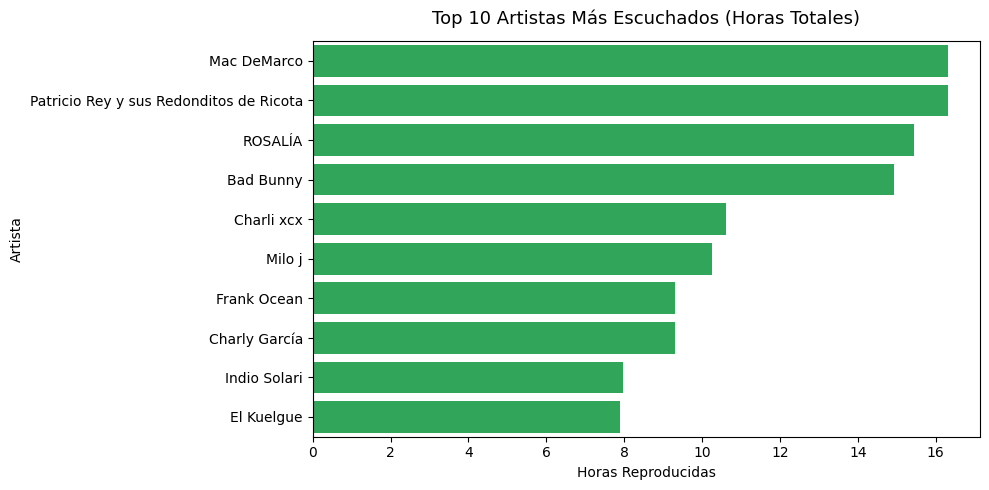

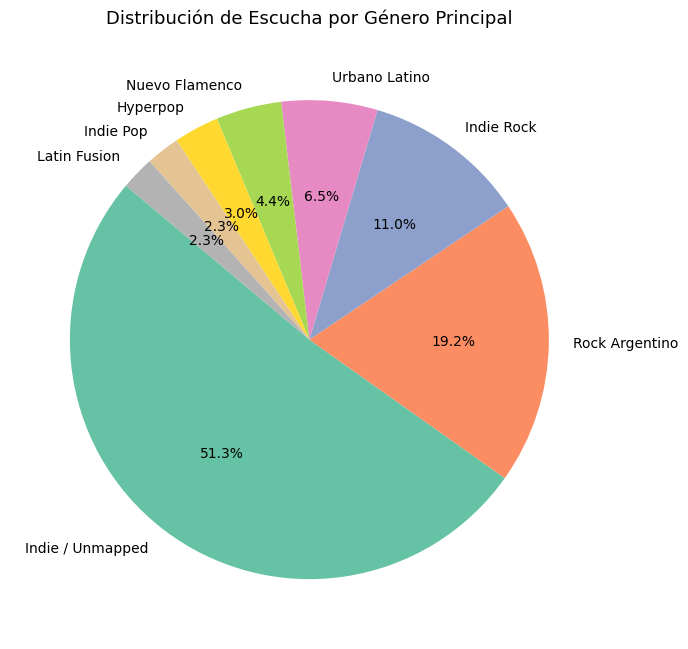

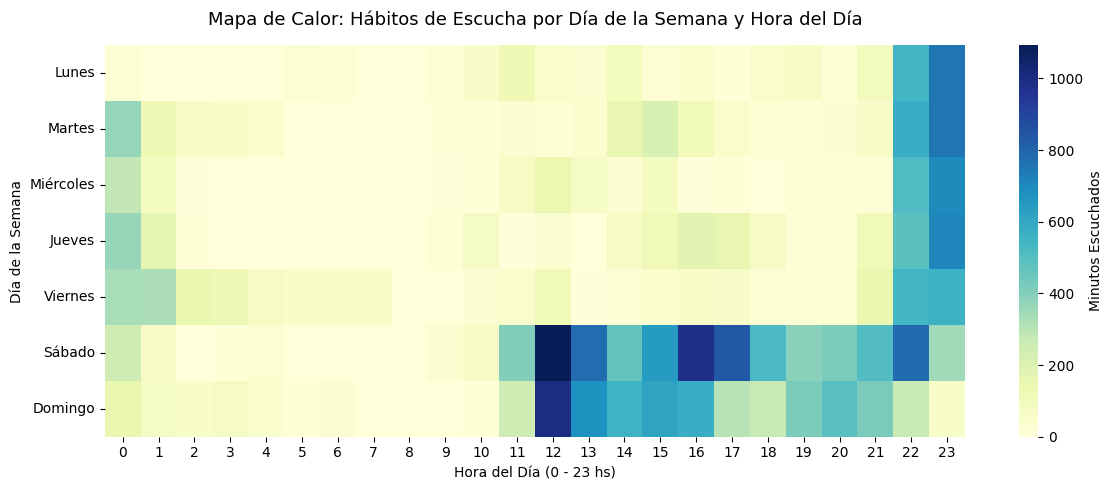

In [15]:
# ==========================================
# VISUALIZACIONES
# ==========================================

COLOR_SPOTIFY = "#1DB954"

if not df_streaming.empty:
    # 1. Top 10 Artistas Más Escuchados (Color Unificado)
    top_artists = (
        df_streaming.groupby("artistName")["hoursPlayed"]
        .sum()
        .nlargest(10)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=top_artists,
        x="hoursPlayed",
        y="artistName",
        color=COLOR_SPOTIFY,  # Ahora se encuentra definida correctamente
    )
    plt.title(
        "Top 10 Artistas Más Escuchados (Horas Totales)", fontsize=13, pad=12
    )
    plt.xlabel("Horas Reproducidas", fontsize=10)
    plt.ylabel("Artista", fontsize=10)
    plt.tight_layout()
    plt.show()

    # 2. Distribución por Género Principal
    top_genres = genre_summary.head(8).reset_index()
    plt.figure(figsize=(7, 7))
    plt.pie(
        top_genres["horas_escuchadas"],
        labels=top_genres["genero_principal"],
        autopct="%1.1f%%",
        startangle=140,
        colors=sns.color_palette("Set2"),
    )
    plt.title(
        "Distribución de Escucha por Género Principal", fontsize=13, pad=12
    )
    plt.tight_layout()
    plt.show()

    # 3. Mapa de Calor (Día de la Semana vs Hora del Día)
    matriz_heatmap = (
        df_streaming.groupby(["dia_semana", "hour"], observed=False)[
            "minutesPlayed"
        ]
        .sum()
        .unstack(fill_value=0)
    )
    plt.figure(figsize=(12, 5))
    sns.heatmap(
        matriz_heatmap,
        cmap="YlGnBu",
        annot=False,
        cbar_kws={"label": "Minutos Escuchados"},
    )
    plt.title(
        "Mapa de Calor: Hábitos de Escucha por Día de la Semana y Hora del Día",
        fontsize=13,
        pad=15,
    )
    plt.xlabel("Hora del Día (0 - 23 hs)", fontsize=10)
    plt.ylabel("Día de la Semana", fontsize=10)
    plt.tight_layout()
    plt.show()

##GENERACIÓN DE CSVs

In [18]:
# ==========================================
# GENERACIÓN Y EXPORTACIÓN DE CSVS
# ==========================================
# 1. Dataset Streaming Enriquecido Base
if not df_streaming.empty:
    df_streaming.to_csv(
        "streaming_history_enriquecido.csv", index=False, encoding="utf-8-sig"
    )

if not df_library.empty:
    df_library.to_csv(
        "library_enriquecida.csv", index=False, encoding="utf-8-sig"
    )

# 2. KPIs Generales por Género
if "genre_summary" in locals() and not genre_summary.empty:
    genre_summary.reset_index().to_csv(
        "kpi_generos_summary.csv", index=False, encoding="utf-8-sig"
    )

# 3. Resumen Diario por Género
if not df_streaming.empty:
    resumen_generos_diario = (
        df_streaming.groupby(
            ["Fecha", "genero_principal", "generos_secundarios"],
            as_index=False,
        )
        .agg(
            cantidad_reproducciones=("trackName", "count"),
            msPlayed=("msPlayed", "sum"),
            minutosPlayed=("minutesPlayed", "sum"),
        )
        .sort_values(by=["Fecha", "msPlayed"], ascending=[True, False])
    )
    resumen_generos_diario.to_csv(
        "Resumen_Generos_Diario.csv", index=False, encoding="utf-8-sig"
    )

    # 4. Matriz Diaria Top 10 Artistas
    top_10_artistas = (
        df_streaming.groupby("artistName")["msPlayed"]
        .sum()
        .nlargest(10)
        .index.tolist()
    )
    matriz_top10 = (
        df_streaming[df_streaming["artistName"].isin(top_10_artistas)]
        .pivot_table(
            index="Fecha",
            columns="artistName",
            values="msPlayed",
            aggfunc="sum",
        )
        .fillna(0)
    )
    matriz_top10["Total_msPlayed_Diario"] = matriz_top10.sum(axis=1)
    matriz_top10.reset_index().to_csv(
        "Matriz_Diaria_Top10_Artistas.csv", index=False, encoding="utf-8-sig"
    )

# 5. Ranking de Librería Cruzado con Streaming
if not df_library.empty:
    art_col = (
        "artist"
        if "artist" in df_library.columns
        else ("artistName" if "artistName" in df_library.columns else None)
    )

    if art_col:
        ranking_lib = (
            df_library.groupby(
                [art_col, "genero_principal", "generos_secundarios"],
                as_index=False,
            )
            .agg(canciones_guardadas=("track", "count"))
            .rename(columns={art_col: "artistName"})
        )
        stats_stream = df_streaming.groupby("artistName", as_index=False).agg(
            reproducciones_totales=("trackName", "count"),
            msPlayed_totales=("msPlayed", "sum"),
            minutosPlayed_totales=("minutesPlayed", "sum"),
        )
        ranking_completo = pd.merge(
            ranking_lib, stats_stream, on="artistName", how="left"
        ).fillna(0)
        ranking_completo = ranking_completo.sort_values(
            by=["canciones_guardadas", "reproducciones_totales"],
            ascending=[False, False],
        )
        ranking_completo.to_csv(
            "Ranking_Libreria_Artistas.csv", index=False, encoding="utf-8-sig"
        )

# 6. CSVs para Mapa de Calor (Formatos Tabla y Matriz)
if not df_streaming.empty:
    heatmap_data = (
        df_streaming.groupby(["dia_semana", "hour"])
        .agg(
            cantidad_reproducciones=("trackName", "count"),
            msPlayed=("msPlayed", "sum"),
            minutosPlayed=("minutesPlayed", "sum"),
        )
        .reset_index()
    )

    heatmap_data.to_csv(
        "Heatmap_Dia_Hora_Streaming.csv", index=False, encoding="utf-8-sig"
    )

    matriz_heatmap_export = heatmap_data.pivot(
        index="dia_semana", columns="hour", values="minutosPlayed"
    ).fillna(0)

    matriz_heatmap_export.to_csv(
        "Matriz_Heatmap_Dia_Hora.csv", encoding="utf-8-sig"
    )

print("=" * 50)
print("¡EXPORTACIÓN COMPLETADA CON ÉXITO!")
print("Se generaron todos los archivos CSV.")
print("=" * 50)

¡EXPORTACIÓN COMPLETADA CON ÉXITO!
Se generaron todos los archivos CSV.


/tmp/ipykernel_61604/457791554.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_streaming.groupby(["dia_semana", "hour"])
